# Home Credit Default Risk — Notebook 00  
## Baseline Logistic Regression (Application Data Only)

This notebook builds a **baseline Probability of Default (PD)** model using only application-level data.

It establishes a clear **reference model** before introducing external bureau and behavioural features in later notebooks.


## 1. Purpose of this notebook

This notebook answers a simple question:

> How well can we predict default risk using only application data?

This is important because it:

- provides a **baseline benchmark**
- helps measure the **incremental value of external data later**
- reflects how models are often first built in practice

At the end of this notebook, we will have:

- a trained logistic regression model
- baseline evaluation metrics
- exported outputs for later use


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

DATA_DIR = Path("../data/raw")
OUTPUT_DIR = Path("../output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Data directory:", DATA_DIR.resolve())
print("Output directory:", OUTPUT_DIR.resolve())


Data directory: D:\Jane\Job Search\Github\bank\github project\scorecard pd ead consummer credit\data\raw
Output directory: D:\Jane\Job Search\Github\bank\github project\scorecard pd ead consummer credit\output


## 2. Load the application data

This baseline notebook uses only `application_train.csv`, which contains the target variable.

- `TARGET = 1` → default
- `TARGET = 0` → non-default


In [2]:
df = pd.read_csv(DATA_DIR / "application_train.csv")

print("Shape:", df.shape)
df.head()


Shape: (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

## 3. Review the target balance

Credit datasets are usually imbalanced, with far fewer defaults than non-defaults.  
That is normal and important to recognise before modelling.


In [3]:
target_count = df["TARGET"].value_counts().sort_index()
target_ratio = df["TARGET"].value_counts(normalize=True).sort_index()

print("Target count:")
print(target_count)
print()
print("Target ratio:")
print(target_ratio)


Target count:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Target ratio:
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


## 4. Quick data quality review

Before building features, it is useful to review:

- data types
- non-null counts
- missing values


In [4]:
summary = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "non_null_count": df.notnull().sum().values,
    "missing_pct": (df.isnull().mean().values * 100).round(2)
}).sort_values("missing_pct", ascending=False)

summary.head(20)


,column,dtype,non_null_count,missing_pct
48,COMMONAREA_AVG,float64,92646,69.87
62,COMMONAREA_MODE,float64,92646,69.87
76,COMMONAREA_MEDI,float64,92646,69.87
84,NONLIVINGAPARTMENTS_MEDI,float64,93997,69.43
70,NONLIVINGAPARTMENTS_MODE,float64,93997,69.43
56,NONLIVINGAPARTMENTS_AVG,float64,93997,69.43
86,FONDKAPREMONT_MODE,object,97216,68.39
54,LIVINGAPARTMENTS_AVG,float64,97312,68.35
82,LIVINGAPARTMENTS_MEDI,float64,97312,68.35
68,LIVINGAPARTMENTS_MODE,float64,97312,68.35


## 5. Basic feature engineering

For the baseline model, we keep the feature logic simple and explainable.

We create a few intuitive variables that reflect:

- affordability
- repayment burden
- leverage
- borrower stability


In [5]:
df["DAYS_EMPLOYED"] = pd.to_numeric(df["DAYS_EMPLOYED"], errors="coerce")
df["DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].replace(365243, np.nan)

df["DTI"] = df["AMT_CREDIT"] / df["AMT_INCOME_TOTAL"].replace(0, np.nan)
df["INST_TO_INCOME"] = df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"].replace(0, np.nan)
df["LTV_PROXY"] = df["AMT_CREDIT"] / df["AMT_GOODS_PRICE"].replace(0, np.nan)
df["AGE"] = -df["DAYS_BIRTH"] / 365
df["EMPLOYMENT_YEARS"] = -df["DAYS_EMPLOYED"] / 365


## 6. Define the baseline feature set

This baseline set focuses on:

- income
- credit amount
- annuity burden
- leverage proxy
- age and employment stability
- household burden


In [6]:
features = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "DTI",
    "INST_TO_INCOME",
    "LTV_PROXY",
    "AGE",
    "EMPLOYMENT_YEARS",
    "CNT_CHILDREN"
]

target = "TARGET"

df_model = df[features + [target]].replace([np.inf, -np.inf], np.nan).dropna()

print("Model dataset shape:", df_model.shape)
df_model.head()


Model dataset shape: (251869, 10)


,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,DTI,INST_TO_INCOME,LTV_PROXY,AGE,EMPLOYMENT_YEARS,CNT_CHILDREN,TARGET
0,202500.0,406597.5,24700.5,2.007889,0.121978,1.158397,25.920548,1.745205,0,1
1,270000.0,1293502.5,35698.5,4.790750,0.132217,1.145199,45.931507,3.254795,0,0
2,67500.0,135000.0,6750.0,2.000000,0.100000,1.000000,52.180822,0.616438,0,0
3,135000.0,312682.5,29686.5,2.316167,0.219900,1.052803,52.068493,8.326027,0,0
4,121500.0,513000.0,21865.5,4.222222,0.179963,1.000000,54.608219,8.323288,0,0


## 7. Split into train and test samples

This allows us to evaluate model performance on unseen data.


In [7]:
X = df_model[features].copy()
y = df_model[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)


Train shape: (176308, 9)
Test shape : (75561, 9)


## 8. Train the logistic regression model

Logistic regression is widely used in credit risk because it is:

- interpretable
- stable
- easy to validate
- a natural foundation for later scorecard work


In [8]:
model = LogisticRegression(max_iter=1000, solver="liblinear")
model.fit(X_train, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

## 9. Evaluate discrimination power

We use ROC AUC as the main baseline metric.


In [9]:
y_pred_proba = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_pred_proba)
print("Baseline AUC:", round(auc, 4))


Baseline AUC: 0.5336


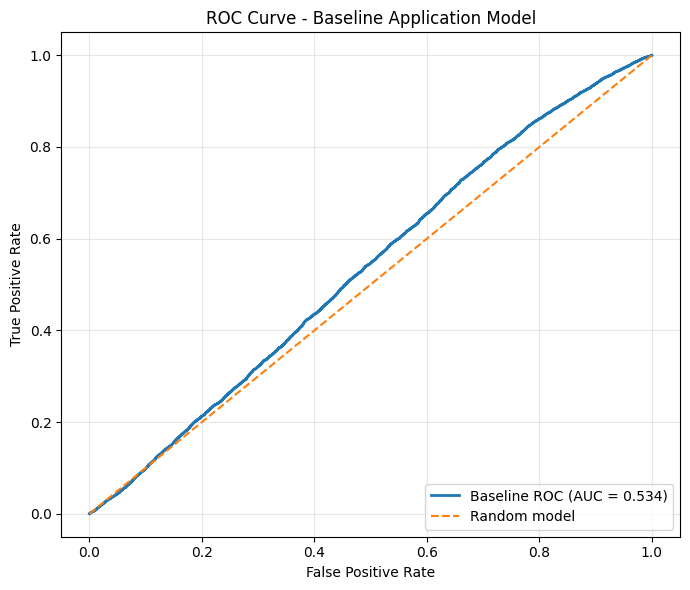

In [10]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, linewidth=2, label=f"Baseline ROC (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1.5, label="Random model")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Baseline Application Model")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 10. Review model coefficients

The coefficient table helps explain which variables increase or reduce default risk.


In [11]:
coef_table = pd.DataFrame({
    "feature": features,
    "coefficient": model.coef_[0]
})

coef_table["odds_ratio"] = np.exp(coef_table["coefficient"])
coef_table["direction"] = np.where(
    coef_table["coefficient"] > 0,
    "Higher default risk",
    "Lower default risk"
)

coef_table = coef_table.sort_values("coefficient", ascending=False).reset_index(drop=True)
coef_table


,feature,coefficient,odds_ratio,direction
0,INST_TO_INCOME,-6.364610e-08,1.000000,Lower default risk
1,CNT_CHILDREN,-2.278148e-07,1.000000,Lower default risk
2,AMT_CREDIT,-4.705224e-07,1.000000,Lower default risk
3,LTV_PROXY,-4.999441e-07,1.000000,Lower default risk
4,DTI,-1.292807e-06,0.999999,Lower default risk
5,EMPLOYMENT_YEARS,-4.933945e-06,0.999995,Lower default risk
6,AMT_INCOME_TOTAL,-7.208091e-06,0.999993,Lower default risk
7,AGE,-2.138601e-05,0.999979,Lower default risk
8,AMT_ANNUITY,-2.980686e-05,0.999970,Lower default risk


## 11. Export key outputs

These exports make the notebook easier to connect with later notebooks and portfolio review.


In [12]:
predictions_test = pd.DataFrame({
    "actual_target": y_test.values,
    "pred_pd": y_pred_proba
})

model_metrics = pd.DataFrame({
    "metric": ["baseline_auc", "train_rows", "test_rows", "n_features"],
    "value": [auc, len(X_train), len(X_test), len(features)]
})

selected_features_df = pd.DataFrame({"feature": features})

predictions_test.to_csv(OUTPUT_DIR / "baseline_application_test_predictions.csv", index=False)
model_metrics.to_csv(OUTPUT_DIR / "baseline_application_model_metrics.csv", index=False)
selected_features_df.to_csv(OUTPUT_DIR / "baseline_application_features.csv", index=False)
coef_table.to_csv(OUTPUT_DIR / "baseline_application_coefficients.csv", index=False)

print("Baseline notebook outputs exported.")
print(sorted([p.name for p in OUTPUT_DIR.iterdir() if p.is_file()])[:20])


Baseline notebook outputs exported.
['baseline_application_coefficients.csv', 'baseline_application_features.csv', 'baseline_application_model_metrics.csv', 'baseline_application_test_predictions.csv', 'ead_summary.csv']


## 12. Portfolio wrap-up

### What this notebook demonstrates
- a clean baseline PD workflow using application data only
- simple and explainable feature engineering
- logistic regression as an interpretable benchmark
- exported outputs for later comparison

### Why this matters
This notebook creates the baseline reference point.

The next steps are to:
- engineer external bureau and behavioural features
- compare baseline vs enriched model performance
- translate the model into a scorecard workflow

That progression mirrors how a practical credit-risk portfolio project should be structured.
